# Imports

In [ ]:
import pandas as pd
import random
import os
import numpy as np

# ML libraries
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
## Classifiers (multi-class)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# NLP libraries
import spacy
from transformers import AutoModel, AutoTokenizer
import gensim.downloader as api

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42


# Exploring Data

In [ ]:
df_train = pd.read_csv('medical_specialties_train.csv')
df_test = pd.read_csv('medical_specialties_test.csv')

In [ ]:
len(df_train), len(df_test)

(2481, 828)

In [ ]:
df_train['clinical_summary'].iloc[0]

'PREOPERATIVE DIAGNOSIS: , Rotated cuff tear, right shoulder.,POSTOPERATIVE DIAGNOSES:,1.  Rotated cuff tear, right shoulder.,2.  Glenoid labrum tear.,PROCEDURE PERFORMED:,1.  Arthroscopy with arthroscopic glenoid labrum debridement.,2.  Subacromial decompression.,3.  Rotator cuff repair, right shoulder.,SPECIFICATIONS:,  Intraoperative procedure was done at Inpatient Operative Suite, room #1 at ABCD Hospital.  This was done under interscalene and subsequent general anesthetic in the modified beach chair position.,HISTORY AND GROSS FINDINGS: , The patient is a 48-year-old with male who has been suffering increasing right shoulder pain for a number of months prior to surgical intervention.  He was completely refractory to conservative outpatient therapy.  After discussing the alternative care as well as the advantages, disadvantages, risks, complications, and expectations, he elected to undergo the above stated procedure on this date.,Intraarticularly, the joint was observed.  There was

In [ ]:
df_train.head(5)

,clinical_summary,medical_specialty
0,"PREOPERATIVE DIAGNOSIS: , Rotated cuff tear, r...",Surgery
1,"HISTORY AND CLINICAL DATA: ,The patient is an...",General Medicine
2,"REASON FOR REFERRAL: , Cardiac evaluation and ...",Cardiovascular / Pulmonary
3,"SUBJECTIVE:, The patient is admitted for lung...",Cardiovascular / Pulmonary
4,"PREOPERATIVE DIAGNOSES,1. Neck pain with bila...",Orthopedic


## Categories (Medical Specialities)

In [ ]:
medical_specialties_train = df_test['medical_specialty'].unique().tolist()
medical_specialties_test = df_test['medical_specialty'].unique().tolist()

# are they the same?
set(medical_specialties_train) == set(medical_specialties_test)

True

In [ ]:
print(medical_specialties_train)

[' Neurology', ' Surgery', ' Radiology', ' Gastroenterology', ' Consult - History and Phy.', ' General Medicine', ' Orthopedic', ' Cardiovascular / Pulmonary']


# Preprocessing

In [ ]:
# map specialties to 4 categories
specialty_to_category = {
    ' Neurology': 'Medical',
    ' Gastroenterology': 'Medical',
    ' Consult - History and Phy.': 'Medical',
    ' General Medicine': 'Medical',

    ' Surgery': 'Surgical',
    ' Orthopedic': 'Surgical',

    ' Radiology': 'Diagnostics',

    ' Cardiovascular / Pulmonary': 'Cardio/Pulmonary',
}

df_train['specialty_category'] = df_train['medical_specialty'].map(specialty_to_category)
df_test['specialty_category'] = df_test['medical_specialty'].map(specialty_to_category)

/var/folders/23/c3r9crlx4n3bfy61hpxt580m0000gn/T/ipykernel_97889/263634187.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='specialty_category', data=df_train, palette='Set2')


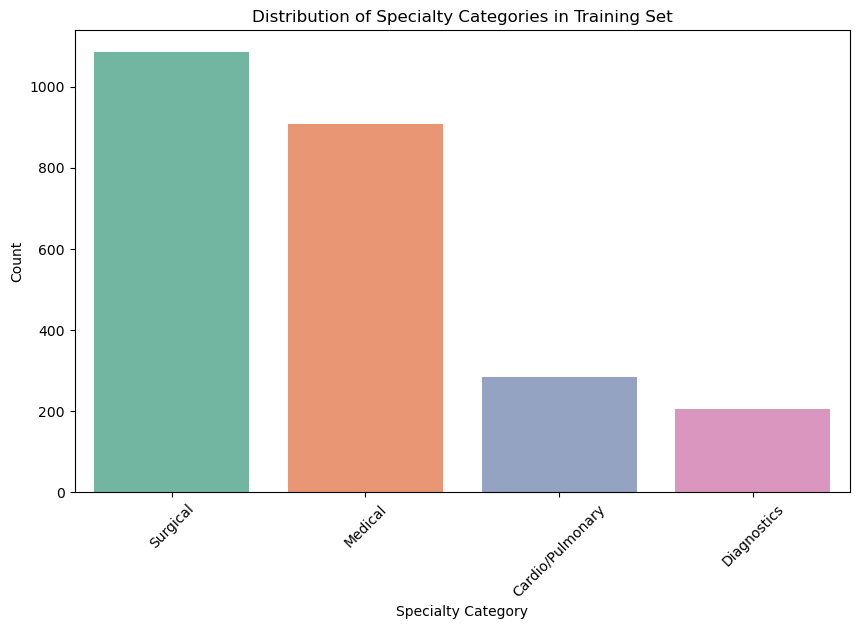

In [ ]:
# bar plot of counts of each specialty category
plt.figure(figsize=(10, 6))
sns.countplot(x='specialty_category', data=df_train, palette='Set2')
plt.title('Distribution of Specialty Categories in Training Set')
plt.xlabel('Specialty Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Clean Text

In [ ]:
def clean_text(text):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    # Remove stop words and lemmatize
    tokens = [token.lemma_.lower() for token in doc if not token.is_stop and token.is_alpha]

    return ' '.join(tokens)

In [ ]:
clean_text_dirs = ['medical_specialties_train_cleaned.csv', 'medical_specialties_test_cleaned.csv']

if all([os.path.exists(d) for d in clean_text_dirs]):
    print("Cleaned files already exist. Skipping cleaning step.")
    train_df = pd.read_csv('medical_specialties_train_cleaned.csv')
    test_df = pd.read_csv('medical_specialties_test_cleaned.csv')
else:
    print("Cleaned files do not exist. Proceeding with cleaning step.")
    # Use clean_text function
    X_train_cleaned = df_train['clinical_summary'].apply(clean_text)
    X_test_cleaned = df_test['clinical_summary'].apply(clean_text)

    # Save cleaned data to csvs (with original labels)
    train_df = pd.DataFrame({'clinical_summary': X_train_cleaned, 'medical_specialty': df_train['medical_specialty'], 'specialty_category': df_train['specialty_category']})
    test_df = pd.DataFrame({'clinical_summary': X_test_cleaned, 'medical_specialty': df_test['medical_specialty'], 'specialty_category': df_test['specialty_category']})

    train_df.to_csv('medical_specialties_train_cleaned.csv', index=False)
    test_df.to_csv('medical_specialties_test_cleaned.csv', index=False)
# takes 16 minutes to run

Cleaned files already exist. Skipping cleaning step.


# Featurisation (from t04)

In [ ]:
# load google news word2vec model from gensim
wv = api.load("word2vec-google-news-300")
# load glove twitter word2vec model from gensim
glv = api.load("glove-twitter-25")
# load tokenizer and model for clinicalBERT
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# Takes 40s to run

In [ ]:
# converting numerical categories using word embeddings w2vec
def pretrained_word2vec(tokens):
    word_vectors = wv.get_mean_vector(tokens)
    return word_vectors

# def custom_word2vec(df, tokens):
#     model = Word2Vec(df['clean_text'], vector_size=300, window=5, min_count=1, workers=4)
#     word_vectors = model.wv
#     mean_vector = word_vectors.get_mean_vector(tokens)

#     return mean_vector

def glove(tokens):

    word_vectors = glv.get_mean_vector(tokens)

    return word_vectors

def bioclinicalbert(tokens):
    inputs = tokenizer(tokens, return_tensors="pt", padding=True, truncation=True,
                       max_length=256 # BioClinicalBERT has a max token limit of 512
            )
    outputs = bert_model(**inputs)

    # Get the mean of the token embeddings
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().detach().numpy()

    return embeddings

embed_dirs = ['train_wv.npy', 'test_wv.npy',
              'train_glv.npy', 'test_glv.npy',
              'train_bert.npy', 'test_bert.npy']

if all([os.path.exists(d) for d in embed_dirs]):
    print("Embedding files already exist. Skipping embedding step.")
    wv_train = np.load('train_wv.npy')
    wv_test = np.load('test_wv.npy')
    glv_train = np.load('train_glv.npy')
    glv_test = np.load('test_glv.npy')
    bert_train = np.load('train_bert.npy')
    bert_test = np.load('test_bert.npy')

    train_df['w2v'] = list(wv_train)
    test_df['w2v'] = list(wv_test)
    train_df['glv'] = list(glv_train)
    test_df['glv'] = list(glv_test)
    train_df['bert'] = list(bert_train)
    test_df['bert'] = list(bert_test)
else:
    print("Embedding files do not exist. Proceeding with embedding step.")

    # W2V
    print("Generating Word2Vec embeddings...")
    train_df['w2v'] = train_df['clinical_summary'].apply(lambda x: pretrained_word2vec(x))
    test_df['w2v'] = test_df['clinical_summary'].apply(lambda x: pretrained_word2vec(x))

    # Glove
    print("Generating GloVe embeddings...")
    train_df['glv'] = train_df['clinical_summary'].apply(lambda x: glove(x))
    test_df['glv'] = test_df['clinical_summary'].apply(lambda x: glove(x))

    # BioClinicalBERT
    print("Generating BioClinicalBERT embeddings...")
    train_df['bert'] = train_df['clinical_summary'].apply(lambda x: bioclinicalbert(x))
    test_df['bert'] = test_df['clinical_summary'].apply(lambda x: bioclinicalbert(x))

    # Save embeddings to npy files
    np.save('train_wv.npy', np.vstack(train_df['w2v'].values))
    np.save('test_wv.npy',  np.vstack(test_df['w2v'].values))
    np.save('train_glv.npy',  np.vstack(train_df['glv'].values))
    np.save('test_glv.npy',  np.vstack(test_df['glv'].values))
    np.save('train_bert.npy',  np.vstack(train_df['bert'].values))
    np.save('test_bert.npy',  np.vstack(test_df['bert'].values))
    # Takes 6 mins to run

Embedding files already exist. Skipping embedding step.


# Preprocessing for ML

In [ ]:
# X_train, X_val, y_train, y_val = train_test_split(train_df[['w2v', 'glv', 'bert']], train_df['specialty_category'], test_size=0.2, random_state=RANDOM_STATE)
X_train = train_df[['w2v', 'glv', 'bert']]
y_train = train_df['specialty_category']

X_test = test_df[['w2v', 'glv', 'bert']]
y_test = test_df['specialty_category']

# encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Model

In [ ]:
embeddings_types = ['w2v', 'glv', 'bert']
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}
model = RandomForestClassifier(random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for embedding in embeddings_types:
    print(f"Training with {embedding} embeddings...")

    X_train_emb = np.vstack(train_df[embedding].values)

    grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='roc_auc_ovr', n_jobs=-1)
    grid_search.fit(X_train_emb, y_train_enc)
    best_model = grid_search.best_estimator_
    print(f"\nBest parameters for {embedding} embeddings: {grid_search.best_params_}")
    print(f"Best cross-validation ROC AUC score for {embedding} embeddings: {grid_search.best_score_}")
    print(f"Average cross-validation ROC AUC scores for {embedding} embeddings: {np.mean(grid_search.cv_results_['mean_test_score'])} +/- {np.mean(grid_search.cv_results_['std_test_score'])}\n")
    model = best_model

    print(f"Testing with {embedding} embeddings...")
    X_test_emb = np.vstack(test_df[embedding].values)

    y_test_pred = model.predict(X_test_emb)
    y_test_pred_proba = model.predict_proba(X_test_emb)

    # Test results
    print(f"\nTest results for {embedding} embeddings:")
    print("Classification Report:")
    print(classification_report(y_test_enc, y_test_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_enc, y_test_pred))
    print("ROC AUC Score:")
    print(roc_auc_score(y_test_enc, y_test_pred_proba, multi_class='ovr')) # use 'ovr' for multi-class classification, macro-average ROC AUC score because of class imbalance
    print("\n" + "="*50 + "\n")




Training with w2v embeddings...

Best parameters for w2v embeddings: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}
Best cross-validation ROC AUC score for w2v embeddings: 0.7654633723066983
Average cross-validation ROC AUC scores for w2v embeddings: 0.7429019902604594 +/- 0.011770505293327137

Testing with w2v embeddings...

Test results for w2v embeddings:
Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.03      0.04        87
           1       0.03      0.01      0.02        69
           2       0.67      0.70      0.68       314
           3       0.64      0.73      0.68       358

    accuracy                           0.59       828
   macro avg       0.35      0.37      0.36       828
weighted avg       0.54      0.59      0.56       828

Confusion Matrix:
[[  3  15  27  42]
 [ 16   1  23  29]
 [  4  11 220  79]
 [ 27  10  59 262]]
ROC AUC Score:
0.7635091631936423


Training with glv embeddings...

B

In [ ]:
# SVC
embeddings_types = ['w2v', 'glv', 'bert']
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
model = SVC(random_state=RANDOM_STATE, probability=True)

for embedding in embeddings_types:
    print(f"Training with {embedding} embeddings...")
    X_train_emb = np.vstack(train_df[embedding].values)
    grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='roc_auc_ovr', n_jobs=-1)
    grid_search.fit(X_train_emb, y_train_enc)
    best_model = grid_search.best_estimator_
    print(f"\nBest parameters for {embedding} embeddings: {grid_search.best_params_}")
    print(f"Best cross-validation ROC AUC score for {embedding} embeddings: {grid_search.best_score_}")
    print(f"Average cross-validation ROC AUC scores for {embedding} embeddings: {np.mean(grid_search.cv_results_['mean_test_score'])} +/- {np.mean(grid_search.cv_results_['std_test_score'])}\n")
    model = best_model

    X_test_emb = np.vstack(test_df[embedding].values)
    y_test_pred = model.predict(X_test_emb)
    y_test_pred_proba = model.predict_proba(X_test_emb)
    print(f"\nTest results for {embedding} embeddings:")
    print("Classification Report:")
    print(classification_report(y_test_enc, y_test_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_enc, y_test_pred))
    print("ROC AUC Score:")
    print(roc_auc_score(y_test_enc, y_test_pred_proba, multi_class='ovr')) # use 'ovr' for multi-class classification, macro-average ROC AUC score because of class imbalance
    print("\n" + "="*50 + "\n")



Training with w2v embeddings...

Best parameters for w2v embeddings: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation ROC AUC score for w2v embeddings: 0.7949242381436848
Average cross-validation ROC AUC scores for w2v embeddings: 0.7823960551376157 +/- 0.010635959266827082


Test results for w2v embeddings:
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.00      0.00      0.00        69
           2       0.66      0.75      0.70       314
           3       0.66      0.87      0.75       358

    accuracy                           0.66       828
   macro avg       0.33      0.40      0.36       828
weighted avg       0.54      0.66      0.59       828

Confusion Matrix:
[[  0   0  39  48]
 [  0   0  34  35]
 [  0   0 235  79]
 [  0   0  47 311]]
ROC AUC Score:
0.8101215623010584


Training with glv embeddings...


/Users/carlos/anaconda3/envs/hds/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carlos/anaconda3/envs/hds/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carlos/anaconda3/envs/hds/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital


Best parameters for glv embeddings: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation ROC AUC score for glv embeddings: 0.7672483328440022
Average cross-validation ROC AUC scores for glv embeddings: 0.7405317093658815 +/- 0.010395728285452608


Test results for glv embeddings:
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.00      0.00      0.00        69
           2       0.61      0.58      0.60       314
           3       0.58      0.87      0.70       358

    accuracy                           0.59       828
   macro avg       0.30      0.36      0.32       828
weighted avg       0.48      0.59      0.53       828

Confusion Matrix:
[[  0   0  38  49]
 [  0   0  29  40]
 [  0   0 182 132]
 [  0   0  48 310]]
ROC AUC Score:
0.784957765935727


Training with bert embeddings...


/Users/carlos/anaconda3/envs/hds/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carlos/anaconda3/envs/hds/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carlos/anaconda3/envs/hds/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital


Best parameters for bert embeddings: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation ROC AUC score for bert embeddings: 0.9129658756736866
Average cross-validation ROC AUC scores for bert embeddings: 0.8999124722543166 +/- 0.005087258823159184


Test results for bert embeddings:
Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.36      0.36        87
           1       0.46      0.33      0.39        69
           2       0.78      0.81      0.79       314
           3       0.77      0.79      0.78       358

    accuracy                           0.71       828
   macro avg       0.59      0.57      0.58       828
weighted avg       0.71      0.71      0.71       828

Confusion Matrix:
[[ 31  11  19  26]
 [ 18  23  13  15]
 [  9   8 254  43]
 [ 26   8  41 283]]
ROC AUC Score:
0.9100576272211461




# Bag of words and TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(lowercase=True, max_features=200)

X_train_tfidf = vectorizer.fit_transform(train_df['clinical_summary'])
X_test_tfidf = vectorizer.transform(test_df['clinical_summary'])

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}
rf = RandomForestClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring='roc_auc_ovr', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train_enc)
best_model = grid_search.best_estimator_
print(f"\nBest parameters for TF-IDF BoW embeddings: {grid_search.best_params_}")
print(f"Best cross-validation ROC AUC score for TF-IDF BoW embeddings: {grid_search.best_score_}")
print(f"Average cross-validation ROC AUC scores for TF-IDF BoW embeddings: {np.mean(grid_search.cv_results_['mean_test_score'])} +/- {np.mean(grid_search.cv_results_['std_test_score'])}\n")

y_test_pred = best_model.predict(X_test_tfidf)
y_test_pred_proba = best_model.predict_proba(X_test_tfidf)
auc = roc_auc_score(y_test_enc, y_test_pred_proba, multi_class='ovr')
print(f"ROC AUC Score for best model TF-IDF BoW: {auc}")



Best parameters for TF-IDF BoW embeddings: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}
Best cross-validation ROC AUC score for TF-IDF BoW embeddings: 0.8726529388273218
Average cross-validation ROC AUC scores for TF-IDF BoW embeddings: 0.8567169277387904 +/- 0.007242029317153666

ROC AUC Score for best model TF-IDF BoW: 0.8589199980412738


In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
svc = SVC(random_state=RANDOM_STATE, probability=True)
grid_search = GridSearchCV(svc, param_grid, cv=cv, scoring='roc_auc_ovr', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train_enc)
best_model = grid_search.best_estimator_
print(f"\nBest parameters for TF-IDF BoW embeddings: {grid_search.best_params_}")
print(f"Best cross-validation ROC AUC score for TF-IDF BoW embeddings: {grid_search.best_score_}")
print(f"Average cross-validation ROC AUC scores for TF-IDF BoW embeddings: {np.mean(grid_search.cv_results_['mean_test_score'])} +/- {np.mean(grid_search.cv_results_['std_test_score'])}\n")

y_test_pred = best_model.predict(X_test_tfidf)
y_test_pred_proba = best_model.predict_proba(X_test_tfidf)
print(f"\nTest results for TF-IDF BoW embeddings with SVC:")
print("Classification Report:")
print(classification_report(y_test_enc, y_test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test_enc, y_test_pred))
print("ROC AUC Score:")
print(roc_auc_score(y_test_enc, y_test_pred_proba, multi_class='ovr'))


Best parameters for TF-IDF BoW embeddings: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation ROC AUC score for TF-IDF BoW embeddings: 0.8997256979018827
Average cross-validation ROC AUC scores for TF-IDF BoW embeddings: 0.8885089984926343 +/- 0.007571167180903421


Test results for TF-IDF BoW embeddings with SVC:
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.37      0.39        87
           1       0.50      0.36      0.42        69
           2       0.78      0.82      0.80       314
           3       0.78      0.81      0.80       358

    accuracy                           0.73       828
   macro avg       0.62      0.59      0.60       828
weighted avg       0.72      0.73      0.72       828

Confusion Matrix:
[[ 32   9  24  22]
 [ 17  25  16  11]
 [  1   7 259  47]
 [ 26   9  33 290]]
ROC AUC Score:
0.8960859269557349


In [ ]:
# overall top words
feature_names = vectorizer.get_feature_names_out()
class_labels = rf.classes_
feature_importances = rf.feature_importances_

top_idx = np.argsort(feature_importances)[-20:]
top_features = feature_names[top_idx]
print("Top 20 important features for TF-IDF BoW:")
for feature in top_features:
    print(feature)


Top 20 important features for TF-IDF BoW:
rate
normal
suture
heart
place
chest
clear
year
fashion
medical
remove
operating
illness
incision
anesthesia
history
preppe
preoperative
procedure
drape


In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr = OneVsRestClassifier(
    RandomForestClassifier(random_state=RANDOM_STATE)
)


ovr.fit(X_train_tfidf, y_train_enc)

,estimator,RandomForestC...ndom_state=42)
,n_jobs,None
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None


In [ ]:
n = 10
for i, c in enumerate(ovr.classes_):
    importances = ovr.estimators_[i].feature_importances_

    top_idx = np.argsort(importances)[-n:]

    class_name = le.inverse_transform([c])[0]

    print(f"\nTop {n} words for {class_name}")
    for word in feature_names[top_idx]:
        print(word)


Top 10 words for Cardio/Respiratory
stenosis
pressure
rate
vein
french
heart
artery
pulmonary
chest
coronary

Top 10 words for Diagnostics
procedure
left
normal
size
unremarkable
see
old
ct
patient
exam

Top 10 words for Medical
deny
present
clear
year
preppe
medical
procedure
illness
history
drape

Top 10 words for Surgical
recovery
fashion
remove
operating
anesthesia
incision
preppe
preoperative
procedure
drape
